# Notebook 3C — Climate niche differentiation and compound-level negative control

This notebook is the climate-data analogue of Notebook 3S v2.

The main analysis is climate niche differentiation among medicinal plant taxa.

The taxon–compound table is retained as annotation and as a negative-control ML task.

In [1]:
# ============================================================
# 0. Imports and configuration
# ============================================================

import os
import re
import pathlib
import warnings
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score, accuracy_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance

try:
    from scipy.stats import kruskal, spearmanr
    from scipy.cluster.hierarchy import linkage, leaves_list
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
except Exception:
    NETWORKX_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 220)

CONFIG = {
    "project_dir": "climate_notebook3C_niche_outputs",
    "input_dirs": [
        ".",
        "/content",
        "/mnt/data",
        "/content/climate_notebook2_outputs",
        "/content/climate_notebook2_outputs/derived",
        "/content/climate_medicinal_value_dataset_v1",
        "/content/climate_medicinal_value_dataset_v1/derived",
        "/content/climate_medicinal_value_dataset_v1/climate",
    ],
    "binary_compound_target_col": "target_label_for_open_data_classifier",
    "ordinal_compound_target_col": "target_evidence_score",
    "min_taxon_occurrences_for_classification": 20,
    "n_group_folds": 5,
    "figure_dpi": 300,
    "save_pdf": True,
    "random_seed": 42,
}

PROJECT = pathlib.Path(CONFIG["project_dir"]).resolve()
DIRS = {"derived": PROJECT / "derived", "figures": PROJECT / "figures", "tables": PROJECT / "tables"}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

RUN_ID = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
PROJECT

PosixPath('/content/climate_notebook3C_niche_outputs')

In [2]:
# ============================================================
# 1. Utilities
# ============================================================

def safe_name(x, max_len=160):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(x)).strip("_")[:max_len]

def find_input_file(filename, required=True):
    candidates = []
    for d in CONFIG["input_dirs"]:
        d = pathlib.Path(d)
        candidates.append(d / filename)
        if d.exists() and d.is_dir():
            candidates.extend(d.rglob(filename))
    existing = sorted(set([p for p in candidates if p.exists() and p.stat().st_size > 0]), key=lambda p: (len(str(p)), str(p)))
    if not existing:
        if required:
            raise FileNotFoundError(f"Could not find {filename}. Add its folder to CONFIG['input_dirs'].")
        return None
    return existing[0]

def load_tsv_any(filenames, required=True):
    for fn in filenames:
        p = find_input_file(fn, required=False)
        if p is not None:
            df = pd.read_csv(p, sep="\t", dtype=str, low_memory=False)
            print(f"Loaded {fn}: {df.shape} from {p}")
            return df
    if required:
        raise FileNotFoundError(f"None of these files were found: {filenames}")
    return pd.DataFrame()

def write_table(df, path_stem):
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    tsv = path_stem.with_suffix(".tsv")
    df.to_csv(tsv, sep="\t", index=False)
    try:
        df.to_parquet(path_stem.with_suffix(".parquet"), index=False)
    except Exception as e:
        print("Parquet skipped:", e)
    return tsv

def save_figure(fig, name):
    png = DIRS["figures"] / f"{safe_name(name)}.png"
    fig.savefig(png, dpi=CONFIG["figure_dpi"], bbox_inches="tight")
    if CONFIG["save_pdf"]:
        fig.savefig(DIRS["figures"] / f"{safe_name(name)}.pdf", bbox_inches="tight")
    print("Saved:", png)

def panel(ax, label):
    ax.text(-0.10, 1.08, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")

def as_numeric_df(df, cols):
    out = pd.DataFrame(index=df.index)
    for c in cols:
        out[c] = pd.to_numeric(df[c], errors="coerce")
    return out

def short_climate_name(x):
    return str(x).replace("clim_", "").replace("_", " ")

def zscore_df(df):
    num = df.apply(pd.to_numeric, errors="coerce")
    return (num - num.mean(axis=0)) / num.std(axis=0).replace(0, np.nan)

In [4]:
# ============================================================
# 2. Load and prepare inputs
# ============================================================

import zipfile
import os

zip_path = "/content/climate_notebook2_outputs.zip"
extract_dir = "/content/climate_notebook2_outputs"

# Ensure the extraction directory exists
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Extract the zip file if it hasn't been extracted already
# Check for a representative file to avoid re-extracting unnecessarily
# Assuming 'occurrence_climate_features.tsv' is one of the files we need.
representative_file = os.path.join(extract_dir, "occurrence_climate_features.tsv")
if not os.path.exists(representative_file):
    print(f"Extracting {zip_path} to {extract_dir}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")
else:
    print(f"'{representative_file}' already exists, skipping extraction.")

occurrence_raw_df = load_tsv_any(["occurrence_climate_features.tsv", "climate_occurrence_level_spatial_sensitivity_table.tsv"], required=True)
primary_compound_df = load_tsv_any(["climate_primary_taxon_compound_table.tsv"], required=True)

clim_cols_raw = [c for c in occurrence_raw_df.columns if c.startswith("clim_")]
if not clim_cols_raw:
    raise RuntimeError("No climate feature columns found.")

metadata_keep = [
    "taxon_id", "input_taxon", "scientific_name", "family", "rank", "priority",
    "gbif_key", "spatial_block_id", "decimal_latitude", "decimal_longitude",
    "block_centroid_latitude", "block_centroid_longitude",
    "geo_stratum", "country", "country_code", "basis_of_record",
]
metadata_keep = [c for c in metadata_keep if c in occurrence_raw_df.columns]

dedup_keys = [c for c in ["taxon_id", "gbif_key", "spatial_block_id", "decimal_latitude", "decimal_longitude"] if c in occurrence_raw_df.columns]
if "gbif_key" not in dedup_keys:
    dedup_keys = [c for c in ["taxon_id", "spatial_block_id", "decimal_latitude", "decimal_longitude"] if c in occurrence_raw_df.columns]

occurrence_climate_df = occurrence_raw_df[metadata_keep + clim_cols_raw].drop_duplicates(subset=dedup_keys).copy()

for c in clim_cols_raw:
    occurrence_climate_df[c] = pd.to_numeric(occurrence_climate_df[c], errors="coerce")

climate_feature_cols = [
    c for c in clim_cols_raw
    if occurrence_climate_df[c].notna().sum() >= 3 and occurrence_climate_df[c].nunique(dropna=True) > 1
]

occurrence_climate_df["has_complete_climate_vector"] = occurrence_climate_df[climate_feature_cols].notna().all(axis=1)
occurrence_climate_df = occurrence_climate_df[occurrence_climate_df["has_complete_climate_vector"]].copy()

if "input_taxon" not in occurrence_climate_df.columns:
    occurrence_climate_df["input_taxon"] = occurrence_climate_df.get("scientific_name", occurrence_climate_df["taxon_id"])

for c in [CONFIG["binary_compound_target_col"], CONFIG["ordinal_compound_target_col"]]:
    if c in primary_compound_df.columns:
        primary_compound_df[c] = pd.to_numeric(primary_compound_df[c], errors="coerce").fillna(0).astype(int)

compound_annotation_df = primary_compound_df.copy()

write_table(occurrence_climate_df, DIRS["derived"] / "climate_niche_occurrence_table_deduplicated")
write_table(pd.DataFrame({"climate_feature": climate_feature_cols}), DIRS["derived"] / "climate_niche_feature_list")

print("Climate niche rows:", len(occurrence_climate_df))
print("Climate features:", len(climate_feature_cols))
display(occurrence_climate_df.head())

Extracting /content/climate_notebook2_outputs.zip to /content/climate_notebook2_outputs...
Extraction complete.
Loaded climate_occurrence_level_spatial_sensitivity_table.tsv: (22104, 116) from climate_notebook2_outputs/derived/climate_occurrence_level_spatial_sensitivity_table.tsv
Loaded climate_primary_taxon_compound_table.tsv: (48, 133) from climate_notebook2_outputs/derived/climate_primary_taxon_compound_table.tsv
Climate niche rows: 2763
Climate features: 62


,taxon_id,input_taxon,scientific_name,family,rank,priority,gbif_key,spatial_block_id,decimal_latitude,decimal_longitude,block_centroid_latitude,block_centroid_longitude,geo_stratum,country,country_code,basis_of_record,clim_tmean_annual,clim_tmean_seasonality_sd,clim_tmean_range,clim_tmax_warmest_month,clim_tmin_coldest_month,clim_temp_extreme_range,clim_mean_diurnal_range,clim_precip_annual,clim_precip_wettest_month,clim_precip_driest_month,clim_precip_seasonality_cv,clim_aridity_index_precip_over_tmean_plus10,clim_precip_wettest_quarter,clim_precip_driest_quarter,clim_tmean_warmest_quarter,clim_tmean_coldest_quarter,clim_tmean_wettest_quarter,clim_tmean_driest_quarter,clim_precip_warmest_quarter,clim_precip_coldest_quarter,clim_rh2m_annual,clim_rh2m_seasonality_sd,clim_solar_annual_mean,clim_solar_seasonality_sd,clim_wind_annual_mean,clim_wind_seasonality_sd,clim_T2M_JAN,clim_PRECTOTCORR_JAN,clim_RH2M_JAN,clim_T2M_FEB,clim_PRECTOTCORR_FEB,clim_RH2M_FEB,clim_T2M_MAR,clim_PRECTOTCORR_MAR,clim_RH2M_MAR,clim_T2M_APR,clim_PRECTOTCORR_APR,clim_RH2M_APR,clim_T2M_MAY,clim_PRECTOTCORR_MAY,clim_RH2M_MAY,clim_T2M_JUN,clim_PRECTOTCORR_JUN,clim_RH2M_JUN,clim_T2M_JUL,clim_PRECTOTCORR_JUL,clim_RH2M_JUL,clim_T2M_AUG,clim_PRECTOTCORR_AUG,clim_RH2M_AUG,clim_T2M_SEP,clim_PRECTOTCORR_SEP,clim_RH2M_SEP,clim_T2M_OCT,clim_PRECTOTCORR_OCT,clim_RH2M_OCT,clim_T2M_NOV,clim_PRECTOTCORR_NOV,clim_RH2M_NOV,clim_T2M_DEC,clim_PRECTOTCORR_DEC,clim_RH2M_DEC,has_complete_climate_vector
0,TAX_SEDUM,Sedum,Sedum album L.,Crassulaceae,genus,project_core,5938036248,173_21,43.283052,5.370825,43.375,5.375,north_temperate__lonsec_6,France,FR,HUMAN_OBSERVATION,14.170000,7.175193,19.33,40.98,-8.02,49.00,28.265833,18.31,3.13,0.42,47.600477,0.757551,7.30,2.06,23.516667,5.723333,10.336667,23.516667,2.06,4.66,70.220833,11.886903,15.965833,7.825818,3.038333,0.145592,5.32,1.56,84.06,5.74,1.35,80.61,8.89,1.28,75.86,12.45,1.57,71.30,16.55,1.52,66.15,21.82,0.97,57.52,24.65,0.42,51.08,24.08,0.67,53.04,19.53,1.67,63.12,15.12,2.42,74.52,9.78,3.13,81.62,6.11,1.75,83.77,True
8,TAX_SEDUM,Sedum,Sedum dasyphyllum L.,Crassulaceae,genus,project_core,5938040436,173_21,43.28408,5.369642,43.375,5.375,north_temperate__lonsec_6,France,FR,HUMAN_OBSERVATION,14.170000,7.175193,19.33,40.98,-8.02,49.00,28.265833,18.31,3.13,0.42,47.600477,0.757551,7.30,2.06,23.516667,5.723333,10.336667,23.516667,2.06,4.66,70.220833,11.886903,15.965833,7.825818,3.038333,0.145592,5.32,1.56,84.06,5.74,1.35,80.61,8.89,1.28,75.86,12.45,1.57,71.30,16.55,1.52,66.15,21.82,0.97,57.52,24.65,0.42,51.08,24.08,0.67,53.04,19.53,1.67,63.12,15.12,2.42,74.52,9.78,3.13,81.62,6.11,1.75,83.77,True
16,TAX_SEDUM,Sedum,Sedum dasyphyllum L.,Crassulaceae,genus,project_core,5938050053,173_21,43.283152,5.370802,43.375,5.375,north_temperate__lonsec_6,France,FR,HUMAN_OBSERVATION,14.170000,7.175193,19.33,40.98,-8.02,49.00,28.265833,18.31,3.13,0.42,47.600477,0.757551,7.30,2.06,23.516667,5.723333,10.336667,23.516667,2.06,4.66,70.220833,11.886903,15.965833,7.825818,3.038333,0.145592,5.32,1.56,84.06,5.74,1.35,80.61,8.89,1.28,75.86,12.45,1.57,71.30,16.55,1.52,66.15,21.82,0.97,57.52,24.65,0.42,51.08,24.08,0.67,53.04,19.53,1.67,63.12,15.12,2.42,74.52,9.78,3.13,81.62,6.11,1.75,83.77,True
24,TAX_SEDUM,Sedum,Sedum album L.,Crassulaceae,genus,project_core,5938051489,193_-494,48.420655,-123.30132,48.375,-123.375,north_temperate__lonsec_1,Canada,CA,HUMAN_OBSERVATION,10.533333,4.542323,12.12,32.26,-7.58,39.84,21.069167,32.55,5.12,0.59,57.042576,1.585227,14.26,2.69,16.413333,5.370000,6.026667,16.190000,3.14,12.13,80.928333,4.439463,12.492500,7.577430,2.270000,0.504759,5.37,4.73,86.92,5.52,2.99,83.38,7.09,3.42,82.32,9.12,2.34,80.13,12.13,1.67,79.29,14.30,1.23,78.40,16.93,0.59,74.57,17.34,0.87,73.71,14.97,1.68,77.16,10.92,3.50,83.34,7.49,5.12,85.80,5.22,4.41,86.12,True
32,TAX_SEDUM,Sedum,Sedum album L.,Crassulaceae,genus,project_core,5938100553,239_42,59.87629,10.605388,59.875,10.625,north_temperate__lonsec_6,Norway,NO,HUMAN_OBSERVATION,4.571667,8.272798,22.09,31

In [6]:
# ============================================================
# 3. QC and block-level feature tables
# ============================================================

taxon_coverage_qc_df = (
    occurrence_climate_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(n_climate_occurrences=("taxon_id", "size"),
         n_spatial_blocks=("spatial_block_id", "nunique") if "spatial_block_id" in occurrence_climate_df.columns else ("taxon_id", "size"),
         n_geo_strata=("geo_stratum", "nunique") if "geo_stratum" in occurrence_climate_df.columns else ("taxon_id", "size"))
)
taxon_coverage_qc_df["suitable_for_taxon_niche_classification"] = taxon_coverage_qc_df["n_climate_occurrences"] >= CONFIG["min_taxon_occurrences_for_classification"]

feature_completeness_df = pd.DataFrame({
    "climate_feature": climate_feature_cols,
    "n_nonmissing": [occurrence_climate_df[c].notna().sum() for c in climate_feature_cols],
    "pct_nonmissing": [100 * occurrence_climate_df[c].notna().mean() for c in climate_feature_cols],
    "n_unique": [occurrence_climate_df[c].nunique(dropna=True) for c in climate_feature_cols],
})

if "decimal_latitude" in occurrence_climate_df.columns:
    occurrence_climate_df["decimal_latitude"] = pd.to_numeric(occurrence_climate_df["decimal_latitude"], errors="coerce")
if "decimal_longitude" in occurrence_climate_df.columns:
    occurrence_climate_df["decimal_longitude"] = pd.to_numeric(occurrence_climate_df["decimal_longitude"], errors="coerce")

block_keys = [c for c in ["taxon_id", "input_taxon", "spatial_block_id"] if c in occurrence_climate_df.columns]
taxon_block_climate_df = (
    occurrence_climate_df
    .groupby(block_keys, as_index=False)
    .agg(n_occurrences=("taxon_id", "size"),
         decimal_latitude=("decimal_latitude", "mean") if "decimal_latitude" in occurrence_climate_df.columns else ("taxon_id", "size"),
         decimal_longitude=("decimal_longitude", "mean") if "decimal_longitude" in occurrence_climate_df.columns else ("taxon_id", "size"),
         **{c: (c, "mean") for c in climate_feature_cols})
)

write_table(taxon_coverage_qc_df, DIRS["derived"] / "taxon_climate_niche_coverage_qc")
write_table(feature_completeness_df, DIRS["derived"] / "climate_feature_completeness_qc")
write_table(taxon_block_climate_df, DIRS["derived"] / "taxon_spatial_block_climate_table")

display(taxon_coverage_qc_df)


,taxon_id,input_taxon,n_climate_occurrences,n_spatial_blocks,n_geo_strata,suitable_for_taxon_niche_classification
0,TAX_ARTEMISIA_ANNUA,Artemisia annua,512,49,19,True
1,TAX_GLYCYRRHIZA_GLABRA,Glycyrrhiza glabra,456,43,7,True
2,TAX_HYPERICUM,Hypericum,357,72,29,True
3,TAX_RHODIOLA,Rhodiola,416,40,18,True
4,TAX_SEDUM,Sedum,438,63,19,True
5,TAX_TAXUS,Taxus,584,54,11,True


In [7]:
# ============================================================
# 4. Climate PCA and profiles
# ============================================================

X_block = taxon_block_climate_df[climate_feature_cols].apply(pd.to_numeric, errors="coerce")
X_block_imp = SimpleImputer(strategy="median").fit_transform(X_block)
X_block_scaled = StandardScaler().fit_transform(X_block_imp)

n_components = min(5, X_block_scaled.shape[0], X_block_scaled.shape[1])
pca_block = PCA(n_components=n_components, random_state=CONFIG["random_seed"])
block_scores = pca_block.fit_transform(X_block_scaled)

block_pca_scores_df = taxon_block_climate_df[block_keys + ["n_occurrences"]].copy()
for i in range(n_components):
    block_pca_scores_df[f"PC{i+1}"] = block_scores[:, i]

block_pca_loadings_df = pd.DataFrame(pca_block.components_.T, index=climate_feature_cols, columns=[f"PC{i+1}" for i in range(n_components)]).reset_index().rename(columns={"index": "climate_feature"})
block_pca_explained_df = pd.DataFrame({"component": [f"PC{i+1}" for i in range(n_components)], "explained_variance_ratio": pca_block.explained_variance_ratio_, "cumulative_explained_variance": np.cumsum(pca_block.explained_variance_ratio_)})

climate_corr_input = taxon_block_climate_df[climate_feature_cols].apply(pd.to_numeric, errors="coerce")
climate_corr_input = climate_corr_input.loc[:, climate_corr_input.nunique(dropna=True) > 1]
climate_corr = climate_corr_input.corr(method="spearman").fillna(0)
if SCIPY_AVAILABLE and climate_corr.shape[0] > 2:
    dist = 1 - np.abs(climate_corr.values)
    np.fill_diagonal(dist, 0)
    order = leaves_list(linkage(dist, method="average"))
else:
    order = np.arange(climate_corr.shape[0])
climate_corr_ordered = climate_corr.iloc[order, order]

core_features = [c for c in ["clim_tmean_annual", "clim_tmean_seasonality_sd", "clim_tmean_range", "clim_precip_annual", "clim_precip_seasonality_cv", "clim_rh2m_annual", "clim_solar_annual_mean", "clim_wind_annual_mean"] if c in climate_feature_cols]
taxon_climate_profile = occurrence_climate_df.groupby("input_taxon")[core_features].mean()
taxon_climate_profile_z = zscore_df(taxon_climate_profile)

write_table(block_pca_scores_df, DIRS["derived"] / "block_level_climate_pca_scores")
write_table(block_pca_loadings_df, DIRS["derived"] / "block_level_climate_pca_loadings")
write_table(block_pca_explained_df, DIRS["derived"] / "block_level_climate_pca_explained_variance")
write_table(climate_corr.reset_index().rename(columns={"index": "climate_feature"}), DIRS["derived"] / "block_level_climate_feature_spearman_correlation")
write_table(taxon_climate_profile.reset_index(), DIRS["derived"] / "climate_niche_profile_by_taxon_raw_means")
write_table(taxon_climate_profile_z.reset_index(), DIRS["derived"] / "climate_niche_profile_by_taxon_zscores")
block_pca_explained_df

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.354056,0.354056
1,PC2,0.241484,0.595540
2,PC3,0.098894,0.694434
3,PC4,0.076394,0.770828
4,PC5,0.070005,0.840833


In [8]:
# ============================================================
# 5. Taxon climate-niche classification
# ============================================================

eligible_taxa = taxon_coverage_qc_df.loc[taxon_coverage_qc_df["suitable_for_taxon_niche_classification"], "taxon_id"].tolist()
classification_df = occurrence_climate_df[occurrence_climate_df["taxon_id"].isin(eligible_taxa)].copy()

X_taxon = classification_df[climate_feature_cols].copy()
label_encoder = LabelEncoder()
y_taxon = label_encoder.fit_transform(classification_df["taxon_id"].astype(str).values)

if "spatial_block_id" in classification_df.columns and classification_df["spatial_block_id"].nunique() >= CONFIG["n_group_folds"]:
    groups = classification_df["spatial_block_id"].astype(str).values
    cv = GroupKFold(n_splits=min(CONFIG["n_group_folds"], classification_df["spatial_block_id"].nunique()))
    cv_name = "spatial_block_group_kfold"
else:
    groups = classification_df["taxon_id"].astype(str).values
    cv = GroupKFold(n_splits=min(CONFIG["n_group_folds"], classification_df["taxon_id"].nunique()))
    cv_name = "taxon_group_kfold_fallback"

models = {
    "dummy_most_frequent": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", DummyClassifier(strategy="most_frequent"))]),
    "logistic_multinomial": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=3000, class_weight="balanced", multi_class="auto", random_state=CONFIG["random_seed"]))]),
    "random_forest": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestClassifier(n_estimators=500, min_samples_leaf=2, class_weight="balanced", random_state=CONFIG["random_seed"]))]),
    "gradient_boosting": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", GradientBoostingClassifier(random_state=CONFIG["random_seed"]))]),
}

cv_rows = []
pred_rows = []
for model_name, model in models.items():
    fold_id = 0
    for train_idx, test_idx in cv.split(X_taxon, y_taxon, groups=groups):
        if len(np.unique(y_taxon[train_idx])) < 2:
            continue
        m = clone(model)
        try:
            m.fit(X_taxon.iloc[train_idx], y_taxon[train_idx])
            pred = m.predict(X_taxon.iloc[test_idx])
            cv_rows.append({
                "model": model_name, "cv_scheme": cv_name, "fold": fold_id,
                "n_train": len(train_idx), "n_test": len(test_idx),
                "accuracy": accuracy_score(y_taxon[test_idx], pred),
                "balanced_accuracy": balanced_accuracy_score(y_taxon[test_idx], pred),
                "macro_f1": f1_score(y_taxon[test_idx], pred, average="macro", zero_division=0),
            })
            for ix, yy, pp in zip(test_idx, y_taxon[test_idx], pred):
                pred_rows.append({"model": model_name, "cv_scheme": cv_name, "fold": fold_id, "row_index": int(classification_df.index[ix]), "true_taxon_id": label_encoder.inverse_transform([yy])[0], "pred_taxon_id": label_encoder.inverse_transform([pp])[0], "correct": int(yy == pp)})
        except Exception as e:
            cv_rows.append({"model": model_name, "cv_scheme": cv_name, "fold": fold_id, "status": f"error: {e}"})
        fold_id += 1

taxon_cv_df = pd.DataFrame(cv_rows)
taxon_predictions_df = pd.DataFrame(pred_rows)
taxon_cv_summary_df = (
    taxon_cv_df
    .groupby(["model", "cv_scheme"], as_index=False)
    .agg(accuracy_mean=("accuracy", "mean"),
         accuracy_sd=("accuracy", "std"),
         balanced_accuracy_mean=("balanced_accuracy", "mean"),
         balanced_accuracy_sd=("balanced_accuracy", "std"),
         macro_f1_mean=("macro_f1", "mean"),
         macro_f1_sd=("macro_f1", "std"),
         n_valid_folds=("fold", "count"))
)

best_candidates = taxon_cv_summary_df[~taxon_cv_summary_df["model"].eq("dummy_most_frequent")].copy()
if best_candidates.empty:
    best_candidates = taxon_cv_summary_df.copy()
best_model_name = best_candidates.sort_values("balanced_accuracy_mean", ascending=False).iloc[0]["model"]
best_taxon_model = clone(models[best_model_name])
best_taxon_model.fit(X_taxon, y_taxon)

perm = permutation_importance(best_taxon_model, X_taxon, y_taxon, n_repeats=100, random_state=CONFIG["random_seed"], scoring="balanced_accuracy")
climate_importance_df = pd.DataFrame({"climate_feature": climate_feature_cols, "importance_mean": perm.importances_mean, "importance_sd": perm.importances_std}).sort_values("importance_mean", ascending=False)

write_table(taxon_cv_df, DIRS["derived"] / "taxon_climate_niche_classification_fold_results")
write_table(taxon_predictions_df, DIRS["derived"] / "taxon_climate_niche_classification_predictions")
write_table(taxon_cv_summary_df, DIRS["derived"] / "taxon_climate_niche_classification_summary")
write_table(climate_importance_df, DIRS["derived"] / "taxon_climate_niche_permutation_importance")

display(taxon_cv_summary_df.sort_values("balanced_accuracy_mean", ascending=False))
display(climate_importance_df.head(20))

,model,cv_scheme,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,n_valid_folds
2,logistic_multinomial,spatial_block_group_kfold,0.664573,0.130291,0.640822,0.099257,0.632403,0.107483,5
3,random_forest,spatial_block_group_kfold,0.645748,0.110493,0.625886,0.058322,0.612439,0.076742,5
1,gradient_boosting,spatial_block_group_kfold,0.620765,0.109642,0.607500,0.090324,0.598568,0.091789,5
0,dummy_most_frequent,spatial_block_group_kfold,0.211347,0.027742,0.166667,0.000000,0.058041,0.006343,5


,climate_feature,importance_mean,importance_sd
3,clim_tmax_warmest_month,0.211979,0.006401
13,clim_precip_driest_quarter,0.197126,0.006510
18,clim_precip_warmest_quarter,0.166948,0.006538
27,clim_PRECTOTCORR_JAN,0.163390,0.005754
28,clim_RH2M_JAN,0.150552,0.006825
22,clim_solar_annual_mean,0.139751,0.005857
21,clim_rh2m_seasonality_sd,0.132634,0.005923
19,clim_precip_coldest_quarter,0.129382,0.005753
25,clim_wind_seasonality_sd,0.117542,0.004442
33,clim_PRECTOTCORR_MAR,0.115956,0.005037


In [9]:
# ============================================================
# 6. Compound annotation and negative-control ML
# ============================================================

compound_heat = compound_annotation_df.pivot_table(
    index="scientific_name" if "scientific_name" in compound_annotation_df.columns else "taxon_id",
    columns="compound_name" if "compound_name" in compound_annotation_df.columns else "compound_id",
    values=CONFIG["ordinal_compound_target_col"],
    aggfunc="max",
    fill_value=0,
)

compound_ml_df = primary_compound_df.copy()
compound_ml_df[CONFIG["binary_compound_target_col"]] = pd.to_numeric(compound_ml_df[CONFIG["binary_compound_target_col"]], errors="coerce").fillna(0).astype(int)

compound_clim_cols = [
    c for c in compound_ml_df.columns
    if c.startswith("clim_") and pd.to_numeric(compound_ml_df[c], errors="coerce").notna().sum() >= 3 and pd.to_numeric(compound_ml_df[c], errors="coerce").nunique(dropna=True) > 1
]

X_compound = as_numeric_df(compound_ml_df, compound_clim_cols)
y_compound = compound_ml_df[CONFIG["binary_compound_target_col"]].astype(int).values
groups_compound_taxon = compound_ml_df["taxon_id"].astype(str).values
groups_compound_class = compound_ml_df["compound_class"].astype(str).values if "compound_class" in compound_ml_df.columns else compound_ml_df["compound_id"].astype(str).values

compound_models = {
    "dummy_most_frequent": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", DummyClassifier(strategy="most_frequent"))]),
    "logistic_l2_balanced": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear", random_state=CONFIG["random_seed"]))]),
    "random_forest": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestClassifier(n_estimators=500, min_samples_leaf=2, class_weight="balanced", random_state=CONFIG["random_seed"]))]),
}

def evaluate_binary_grouped(X, y, groups, model_dict, scheme_name):
    rows = []
    if len(np.unique(groups)) < 3 or len(np.unique(y)) < 2:
        return pd.DataFrame()
    cv = LeaveOneGroupOut()
    for model_name, model in model_dict.items():
        for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups)):
            if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2:
                rows.append({"scheme": scheme_name, "model": model_name, "fold": fold, "status": "skipped_single_class", "n_test": len(te)})
                continue
            m = clone(model)
            try:
                m.fit(X.iloc[tr], y[tr])
                prob = m.predict_proba(X.iloc[te])[:, 1] if hasattr(m, "predict_proba") else m.predict(X.iloc[te])
                pred = (prob >= 0.5).astype(int)
                rows.append({"scheme": scheme_name, "model": model_name, "fold": fold, "status": "ok", "n_train": len(tr), "n_test": len(te), "balanced_accuracy": balanced_accuracy_score(y[te], pred), "accuracy": accuracy_score(y[te], pred), "f1": f1_score(y[te], pred, zero_division=0)})
            except Exception as e:
                rows.append({"scheme": scheme_name, "model": model_name, "fold": fold, "status": f"error: {e}"})
    return pd.DataFrame(rows)

compound_results_taxon_df = evaluate_binary_grouped(X_compound, y_compound, groups_compound_taxon, compound_models, "leave_one_taxon_out")
compound_results_class_df = evaluate_binary_grouped(X_compound, y_compound, groups_compound_class, compound_models, "leave_one_compound_class_out")
compound_negative_control_df = pd.concat([compound_results_taxon_df, compound_results_class_df], ignore_index=True)

ok = compound_negative_control_df[compound_negative_control_df["status"].eq("ok")] if not compound_negative_control_df.empty else pd.DataFrame()
if not ok.empty:
    compound_negative_summary_df = ok.groupby(["scheme", "model"], as_index=False).agg(balanced_accuracy_mean=("balanced_accuracy", "mean"), balanced_accuracy_sd=("balanced_accuracy", "std"), accuracy_mean=("accuracy", "mean"), f1_mean=("f1", "mean"), n_valid_folds=("fold", "count"))
else:
    compound_negative_summary_df = pd.DataFrame()

write_table(compound_heat.reset_index(), DIRS["derived"] / "compound_evidence_annotation_heatmap_matrix")
write_table(pd.DataFrame({"compound_climate_feature": compound_clim_cols}), DIRS["derived"] / "negative_control_compound_climate_feature_list")
write_table(compound_negative_control_df, DIRS["derived"] / "negative_control_compound_level_climate_ml_fold_results")
write_table(compound_negative_summary_df, DIRS["derived"] / "negative_control_compound_level_climate_ml_summary")
display(compound_negative_summary_df)

,scheme,model,balanced_accuracy_mean,balanced_accuracy_sd,accuracy_mean,f1_mean,n_valid_folds
0,leave_one_compound_class_out,dummy_most_frequent,0.50000,0.000000,0.791667,0.00000,8
1,leave_one_compound_class_out,logistic_l2_balanced,0.40625,0.239326,0.500000,0.18750,8
2,leave_one_compound_class_out,random_forest,0.40625,0.239326,0.500000,0.18750,8
3,leave_one_taxon_out,dummy_most_frequent,0.50000,0.000000,0.791667,0.00000,6
4,leave_one_taxon_out,logistic_l2_balanced,0.50000,0.000000,0.375000,0.20202,6
5,leave_one_taxon_out,random_forest,0.50000,0.000000,0.791667,0.00000,6


Saved: /content/climate_notebook3C_niche_outputs/figures/figure1C_climate_niche_design_qc.png


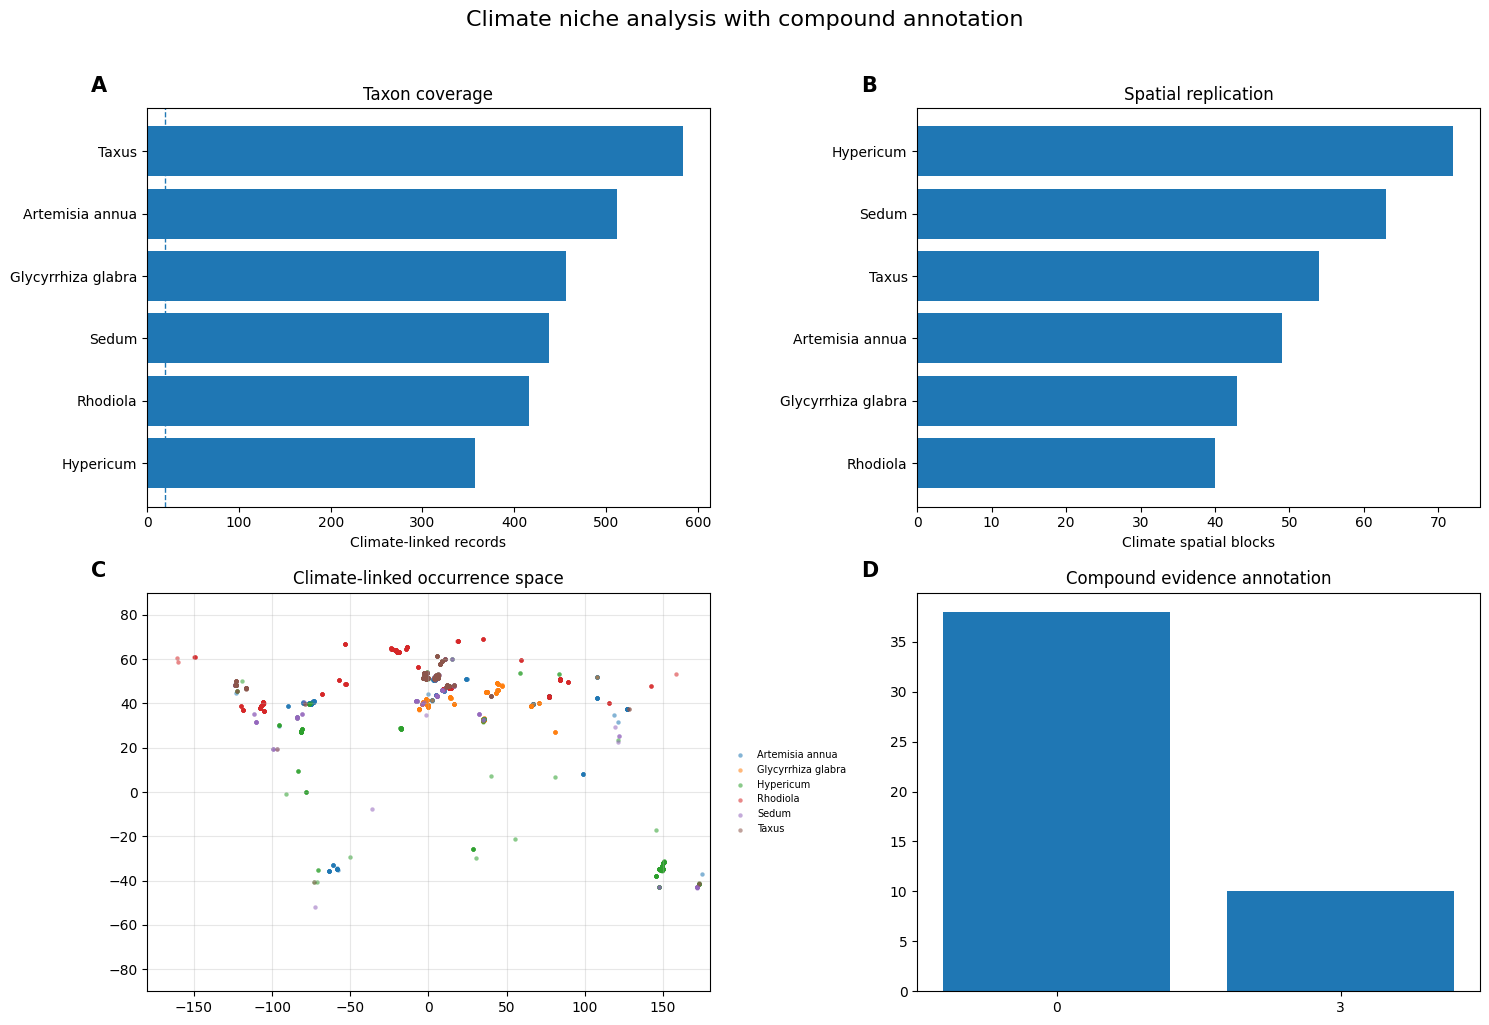

Saved: /content/climate_notebook3C_niche_outputs/figures/figure2C_climate_niche_pca_feature_structure.png


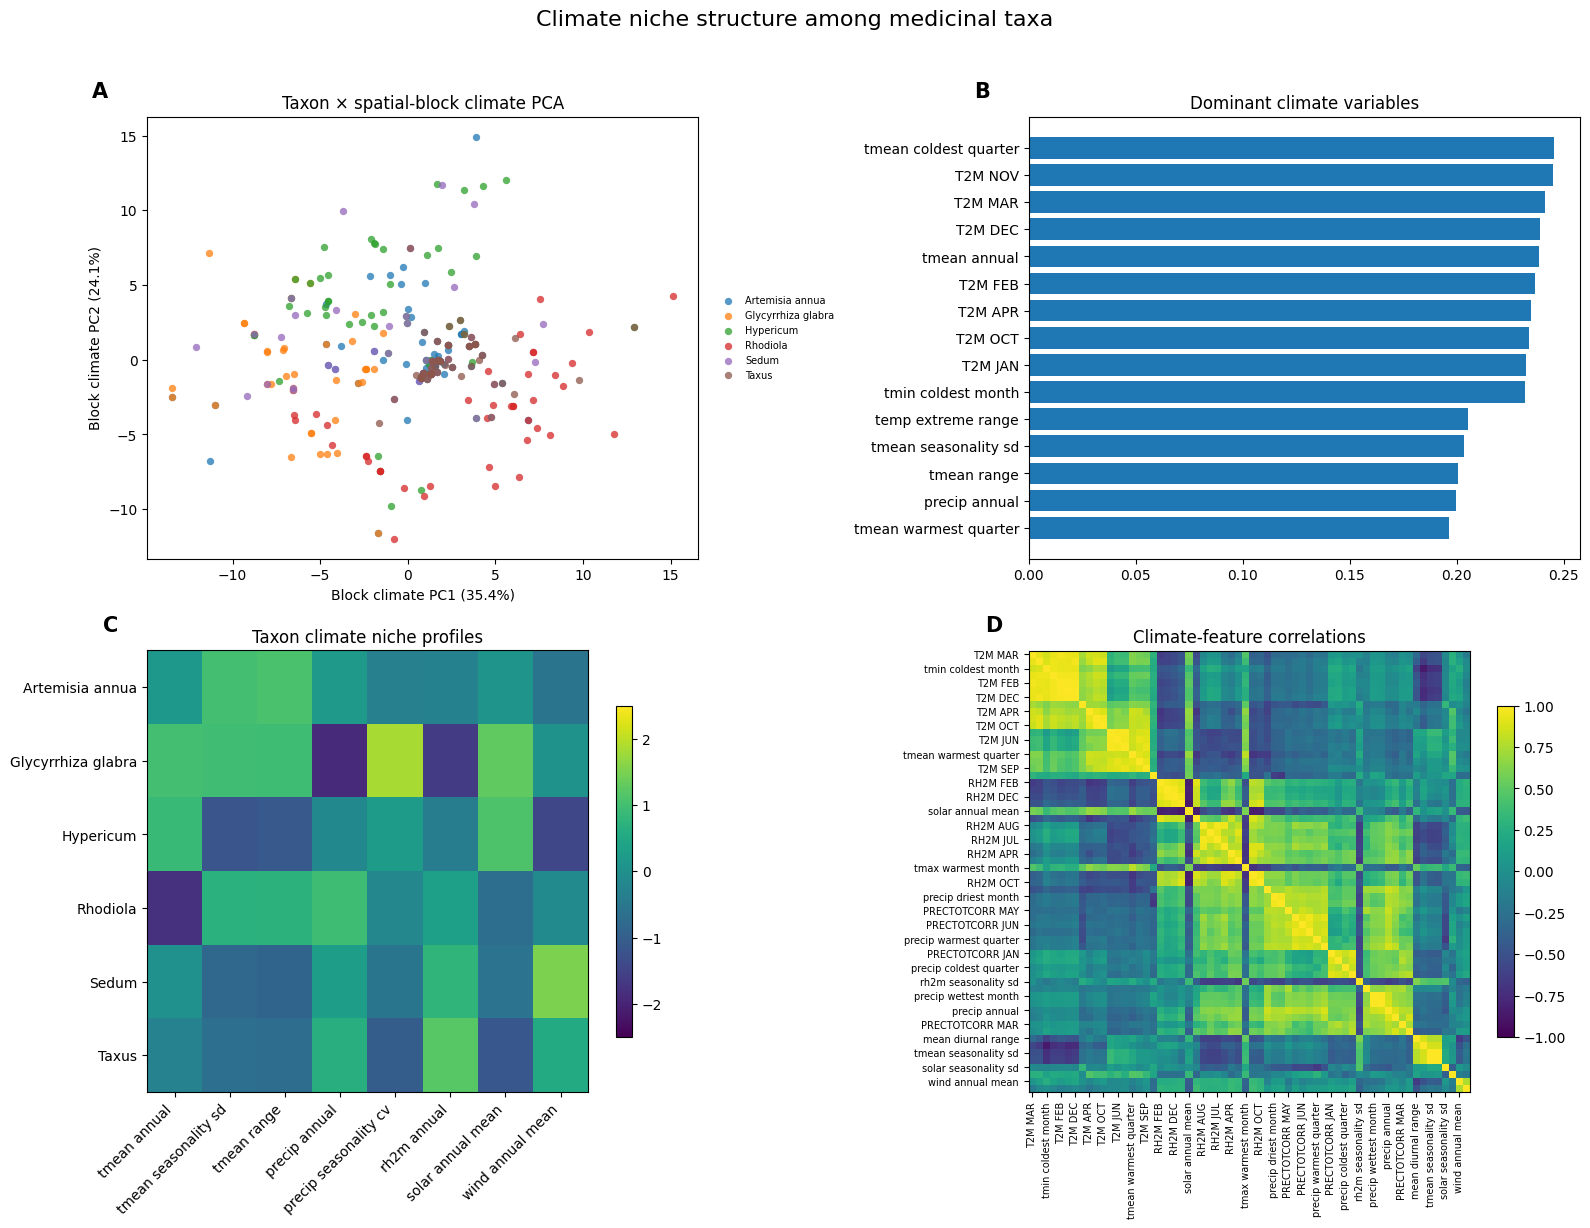

Saved: /content/climate_notebook3C_niche_outputs/figures/figure3C_climate_niche_differentiation_negative_control.png


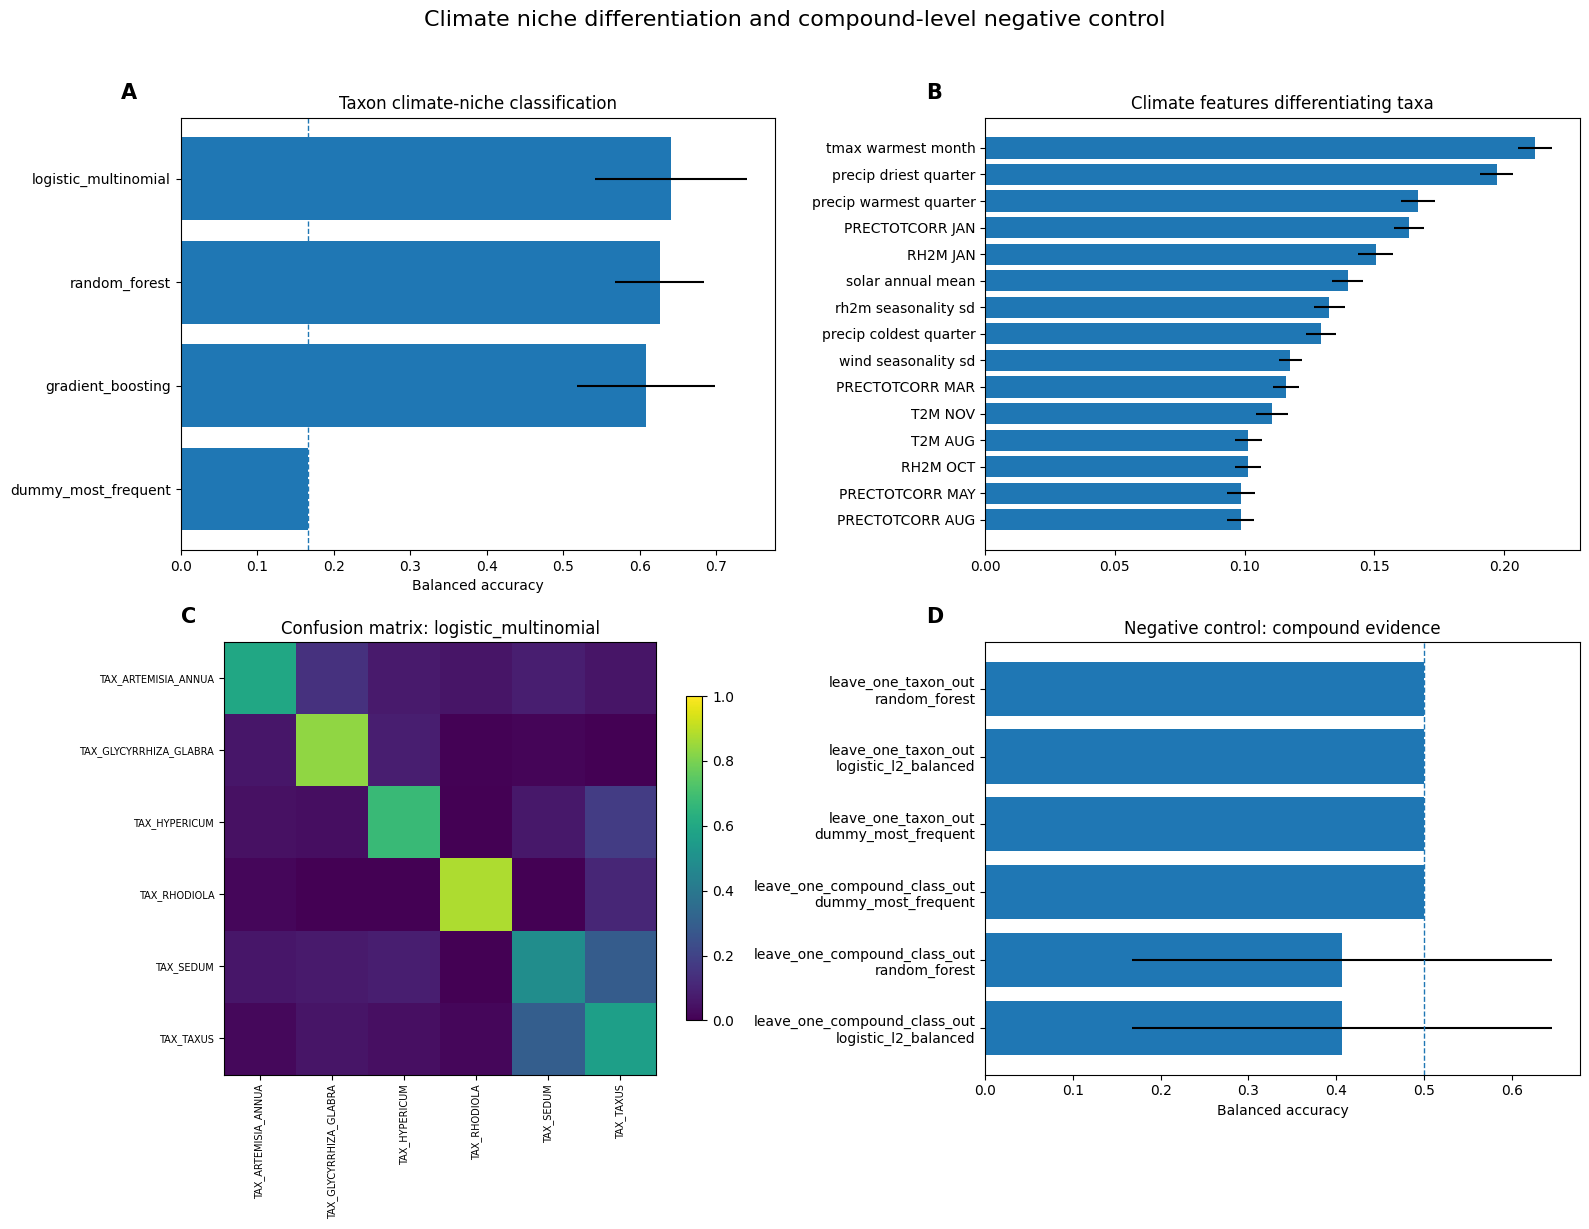

Saved: /content/climate_notebook3C_niche_outputs/figures/figure4C_compound_evidence_annotation.png


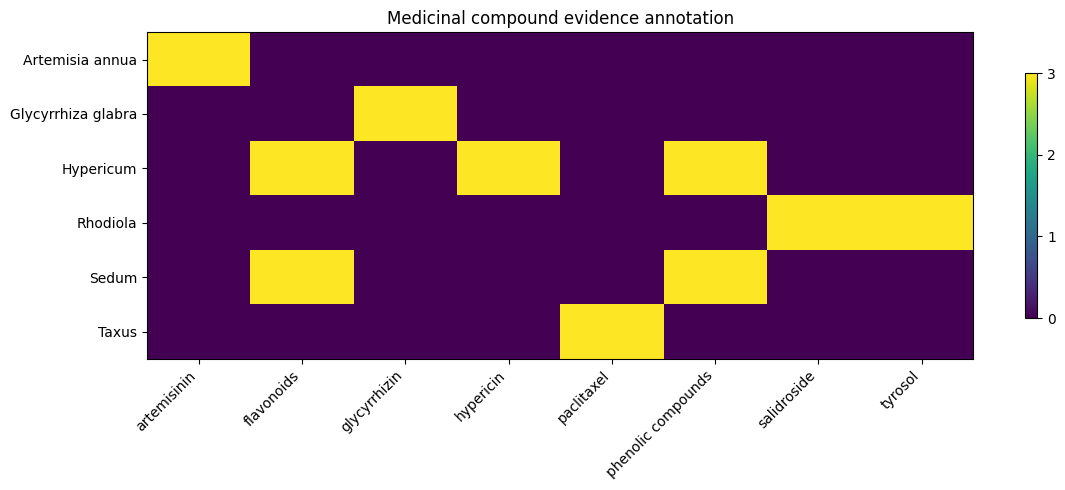

In [10]:
# ============================================================
# 7. Figures
# ============================================================

# Figure 1: QC/design
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.reshape(-1)

plot_df = taxon_coverage_qc_df.sort_values("n_climate_occurrences")
axes[0].barh(plot_df["input_taxon"], plot_df["n_climate_occurrences"])
axes[0].axvline(CONFIG["min_taxon_occurrences_for_classification"], linestyle="--", linewidth=1)
axes[0].set_xlabel("Climate-linked records")
axes[0].set_title("Taxon coverage")
panel(axes[0], "A")

plot_df = taxon_coverage_qc_df.sort_values("n_spatial_blocks")
axes[1].barh(plot_df["input_taxon"], plot_df["n_spatial_blocks"])
axes[1].set_xlabel("Climate spatial blocks")
axes[1].set_title("Spatial replication")
panel(axes[1], "B")

for taxon, sub in occurrence_climate_df.groupby("input_taxon"):
    axes[2].scatter(pd.to_numeric(sub.get("decimal_longitude", sub.get("block_centroid_longitude")), errors="coerce"),
                    pd.to_numeric(sub.get("decimal_latitude", sub.get("block_centroid_latitude")), errors="coerce"),
                    s=10, alpha=0.55, linewidths=0, label=taxon)
axes[2].set_xlim(-180, 180)
axes[2].set_ylim(-90, 90)
axes[2].grid(True, alpha=0.3)
axes[2].set_title("Climate-linked occurrence space")
axes[2].legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
panel(axes[2], "C")

counts = compound_annotation_df[CONFIG["ordinal_compound_target_col"]].value_counts().sort_index()
axes[3].bar([str(x) for x in counts.index], counts.values)
axes[3].set_title("Compound evidence annotation")
panel(axes[3], "D")

fig.suptitle("Climate niche analysis with compound annotation", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure1C_climate_niche_design_qc")
plt.show()

# Figure 2: PCA/profile/correlation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.reshape(-1)

for taxon, sub in block_pca_scores_df.groupby("input_taxon"):
    axes[0].scatter(sub["PC1"], sub["PC2"], s=28, alpha=0.75, linewidths=0, label=taxon)
axes[0].set_xlabel(f"Block climate PC1 ({pca_block.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"Block climate PC2 ({pca_block.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("Taxon × spatial-block climate PCA")
axes[0].legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
panel(axes[0], "A")

load = block_pca_loadings_df.copy()
load["strength"] = np.sqrt(load["PC1"]**2 + load["PC2"]**2)
top_load = load.sort_values("strength", ascending=False).head(15).iloc[::-1]
axes[1].barh([short_climate_name(x) for x in top_load["climate_feature"]], top_load["strength"])
axes[1].set_title("Dominant climate variables")
panel(axes[1], "B")

im = axes[2].imshow(taxon_climate_profile_z.values, aspect="auto", vmin=-2.5, vmax=2.5)
axes[2].set_yticks(range(len(taxon_climate_profile_z.index)))
axes[2].set_yticklabels(taxon_climate_profile_z.index)
axes[2].set_xticks(range(len(taxon_climate_profile_z.columns)))
axes[2].set_xticklabels([short_climate_name(c) for c in taxon_climate_profile_z.columns], rotation=45, ha="right")
axes[2].set_title("Taxon climate niche profiles")
fig.colorbar(im, ax=axes[2], shrink=0.75)
panel(axes[2], "C")

im2 = axes[3].imshow(climate_corr_ordered.values, vmin=-1, vmax=1, interpolation="nearest")
features = climate_corr_ordered.index.tolist()
step = max(1, len(features) // 25)
ticks = list(range(0, len(features), step))
axes[3].set_xticks(ticks)
axes[3].set_yticks(ticks)
axes[3].set_xticklabels([short_climate_name(features[i]) for i in ticks], rotation=90, fontsize=7)
axes[3].set_yticklabels([short_climate_name(features[i]) for i in ticks], fontsize=7)
axes[3].set_title("Climate-feature correlations")
fig.colorbar(im2, ax=axes[3], shrink=0.75)
panel(axes[3], "D")

fig.suptitle("Climate niche structure among medicinal taxa", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure2C_climate_niche_pca_feature_structure")
plt.show()

# Figure 3: model differentiation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.reshape(-1)

plot_df = taxon_cv_summary_df.sort_values("balanced_accuracy_mean")
axes[0].barh(plot_df["model"], plot_df["balanced_accuracy_mean"], xerr=plot_df["balanced_accuracy_sd"].fillna(0))
axes[0].axvline(1 / occurrence_climate_df["taxon_id"].nunique(), linestyle="--", linewidth=1)
axes[0].set_xlabel("Balanced accuracy")
axes[0].set_title("Taxon climate-niche classification")
panel(axes[0], "A")

top_imp = climate_importance_df.head(15).iloc[::-1]
axes[1].barh([short_climate_name(x) for x in top_imp["climate_feature"]], top_imp["importance_mean"], xerr=top_imp["importance_sd"])
axes[1].set_title("Climate features differentiating taxa")
panel(axes[1], "B")

pred_best = taxon_predictions_df[taxon_predictions_df["model"].eq(best_model_name)].copy()
labels = label_encoder.classes_
cm = confusion_matrix(pred_best["true_taxon_id"], pred_best["pred_taxon_id"], labels=labels)
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
im = axes[2].imshow(cm_norm, vmin=0, vmax=1)
axes[2].set_xticks(range(len(labels)))
axes[2].set_yticks(range(len(labels)))
axes[2].set_xticklabels(labels, rotation=90, fontsize=7)
axes[2].set_yticklabels(labels, fontsize=7)
axes[2].set_title(f"Confusion matrix: {best_model_name}")
fig.colorbar(im, ax=axes[2], shrink=0.75)
panel(axes[2], "C")

if not compound_negative_summary_df.empty:
    neg = compound_negative_summary_df.sort_values("balanced_accuracy_mean")
    labels2 = neg["scheme"] + "\n" + neg["model"]
    axes[3].barh(labels2, neg["balanced_accuracy_mean"], xerr=neg["balanced_accuracy_sd"].fillna(0))
    axes[3].axvline(0.5, linestyle="--", linewidth=1)
    axes[3].set_xlabel("Balanced accuracy")
else:
    axes[3].text(0.5, 0.5, "No compound negative-control result", ha="center", va="center")
axes[3].set_title("Negative control: compound evidence")
panel(axes[3], "D")

fig.suptitle("Climate niche differentiation and compound-level negative control", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure3C_climate_niche_differentiation_negative_control")
plt.show()

# Figure 4: compound annotation
fig, ax = plt.subplots(figsize=(12, max(5, 0.55 * len(compound_heat))))
im = ax.imshow(compound_heat.values, aspect="auto", vmin=0, vmax=3)
ax.set_yticks(range(len(compound_heat.index)))
ax.set_yticklabels(compound_heat.index)
ax.set_xticks(range(len(compound_heat.columns)))
ax.set_xticklabels(compound_heat.columns, rotation=45, ha="right")
fig.colorbar(im, ax=ax, shrink=0.75, ticks=[0, 1, 2, 3])
ax.set_title("Medicinal compound evidence annotation")
fig.tight_layout()
save_figure(fig, "figure4C_compound_evidence_annotation")
plt.show()

In [11]:
# ============================================================
# 8. Manuscript tables and QC report
# ============================================================

best_bal_acc = taxon_cv_summary_df.loc[taxon_cv_summary_df["model"].eq(best_model_name), "balanced_accuracy_mean"].iloc[0]

compound_best = np.nan
if not compound_negative_summary_df.empty:
    non_dummy = compound_negative_summary_df[~compound_negative_summary_df["model"].str.contains("dummy", case=False, na=False)]
    if not non_dummy.empty:
        compound_best = non_dummy["balanced_accuracy_mean"].max()

table1 = pd.DataFrame([
    {"item": "Deduplicated climate-linked occurrence rows", "value": len(occurrence_climate_df)},
    {"item": "Taxa included", "value": occurrence_climate_df["taxon_id"].nunique()},
    {"item": "Climate feature columns", "value": len(climate_feature_cols)},
    {"item": "Primary analysis", "value": "climate niche differentiation among taxa"},
    {"item": "Secondary analysis", "value": "compound-level climate-only ML negative control"},
    {"item": "Best taxon climate niche model", "value": best_model_name},
    {"item": "Best taxon climate niche balanced accuracy", "value": best_bal_acc},
    {"item": "Best non-dummy compound-level climate-only balanced accuracy", "value": compound_best},
])

write_table(table1, DIRS["tables"] / "table1_climate_niche_study_summary")
write_table(taxon_coverage_qc_df, DIRS["tables"] / "table2_taxon_climate_niche_coverage")
write_table(taxon_cv_summary_df.sort_values("balanced_accuracy_mean", ascending=False), DIRS["tables"] / "table3_taxon_climate_niche_classification")
write_table(climate_importance_df.head(30), DIRS["tables"] / "table4_climate_niche_feature_importance")
write_table(compound_negative_summary_df, DIRS["tables"] / "table5_negative_control_compound_climate_ml")

qc_lines = [
    "# Notebook 3C QC and interpretation report",
    f"Run ID: {RUN_ID}",
    "",
    "## Main conclusion",
    "This notebook treats climate data as a climate-niche layer, not as a standalone compound-prediction layer.",
    "",
    "## Main climate niche analysis",
    f"Deduplicated climate-linked occurrence rows: {len(occurrence_climate_df)}",
    f"Taxa included: {occurrence_climate_df['taxon_id'].nunique()}",
    f"Climate features: {len(climate_feature_cols)}",
    f"Best taxon climate-niche model: {best_model_name}",
    f"Best taxon climate-niche balanced accuracy: {best_bal_acc}",
    "",
    "## Compound-level negative control",
    f"Best non-dummy compound-level climate-only balanced accuracy: {compound_best}",
    "Compound-level evidence is retained as annotation, not as the primary modelling target.",
    "",
    "## Supported manuscript claim",
    "A low-cost climate workflow can characterize climate niche differentiation among medicinal plant taxa and provide ecological context for medicinal-plant prioritization.",
    "",
    "## Unsupported claims",
    "Do not claim that climate alone predicts medicinal compound accumulation.",
    "Do not claim that climate causes salidroside or other metabolites to accumulate.",
]
qc_path = DIRS["derived"] / "notebook3C_qc_and_interpretation_report.md"
qc_path.write_text("\n".join(qc_lines), encoding="utf-8")

manifest_rows = []
for path in PROJECT.rglob("*"):
    if path.is_file():
        manifest_rows.append({"path": str(path.relative_to(PROJECT)), "bytes": path.stat().st_size, "modified_utc": dt.datetime.fromtimestamp(path.stat().st_mtime, tz=dt.timezone.utc).isoformat(timespec="seconds"), "run_id": RUN_ID})
manifest_df = pd.DataFrame(manifest_rows).sort_values("path")
write_table(manifest_df, PROJECT / "run_file_manifest_fast")

display(table1)
print(qc_path)

Parquet skipped: ("Could not convert 'climate niche differentiation among taxa' with type str: tried to convert to int64", 'Conversion failed for column value with type object')


,item,value
0,Deduplicated climate-linked occurrence rows,2763
1,Taxa included,6
2,Climate feature columns,62
3,Primary analysis,climate niche differentiation among taxa
4,Secondary analysis,compound-level climate-only ML negative control
5,Best taxon climate niche model,logistic_multinomial
6,Best taxon climate niche balanced accuracy,0.640822
7,Best non-dummy compound-level climate-only bal...,0.5


/content/climate_notebook3C_niche_outputs/derived/notebook3C_qc_and_interpretation_report.md


In [12]:
import shutil
from google.colab import files

output_dir = "/content/climate_notebook3C_niche_outputs"
zip_path = "/content/climate_notebook3C_niche_outputs.zip"

# Compress the directory into a zip file
print(f"Zipping {output_dir}...")
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', output_dir)
print("Zip file created successfully.")

# Trigger the download
print("Downloading to your PC...")
files.download(zip_path)


Zipping /content/climate_notebook3C_niche_outputs...
Zip file created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>